In [128]:
!pip install -q segmentation-models-pytorch albumentations

import urllib.request, zipfile, os
os.makedirs('data', exist_ok=True)

urllib.request.urlretrieve(
    "https://storage.googleapis.com/duality-public-share/Hackathons/Duality%20Hackathon/Offroad_Segmentation_Training_Dataset.zip",
    "train.zip"
)

urllib.request.urlretrieve(
    "https://storage.googleapis.com/duality-public-share/Hackathons/Duality%20Hackathon/Offroad_Segmentation_testImages.zip", 
    "test.zip"
)

with zipfile.ZipFile("train.zip") as z: 
    z.extractall("data/")

with zipfile.ZipFile("test.zip") as z: 
    z.extractall("data/")

In [135]:
!pip install -q transformers timm albumentations torchmetrics

In [136]:
from pathlib import Path

train_base = Path("data/Offroad_Segmentation_Training_Dataset")

if (train_base / "train").exists():
    print(f"\n Found train folder")
    train_colored = list((train_base / "train").rglob("*.png"))
    print(f" Images in train: {len(train_colored)}")
    
if (train_base / "val").exists():
    print(f"\n Found val folder")
    val_colored = list((train_base / "val").rglob("*.png"))
    print(f" Images in val: {len(val_colored)}")

test_base = Path("data/Offroad_Segmentation_testImages/Color_Images")
test_images = list(test_base.glob("*.png"))
print(f" Test images: {len(test_images)}")

print("\n Sample paths:")
if train_colored:
    print(f"Train image: {train_colored[0]}")
if val_colored:
    print(f"Val image: {val_colored[0]}")
if test_images:
    print(f"Test image: {test_images[0]}")


 Found train folder
 Images in train: 5714

 Found val folder
 Images in val: 634
 Test images: 1002

 Sample paths:
Train image: data/Offroad_Segmentation_Training_Dataset/train/Color_Images/w0000252.png
Val image: data/Offroad_Segmentation_Training_Dataset/val/Color_Images/mt10000134.png
Test image: data/Offroad_Segmentation_testImages/Color_Images/0000777.png


In [137]:
from pathlib import Path

TRAIN_DIR = Path("data/Offroad_Segmentation_Training_Dataset/train")
VAL_DIR = Path("data/Offroad_Segmentation_Training_Dataset/val")
TEST_DIR = Path("data/Offroad_Segmentation_testImages/Color_Images")

print(f"   TRAIN_DIR: {TRAIN_DIR}")
print(f"   VAL_DIR: {VAL_DIR}")
print(f"   TEST_DIR: {TEST_DIR}")

assert TRAIN_DIR.exists(), f"Training dir not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Validation dir not found: {VAL_DIR}"
assert TEST_DIR.exists(), f"Test dir not found: {TEST_DIR}"

   TRAIN_DIR: data/Offroad_Segmentation_Training_Dataset/train
   VAL_DIR: data/Offroad_Segmentation_Training_Dataset/val
   TEST_DIR: data/Offroad_Segmentation_testImages/Color_Images


In [138]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from transformers import SegformerForSemanticSegmentation
from torchmetrics.classification import MulticlassJaccardIndex
from tqdm import tqdm

In [139]:
from pathlib import Path

train_path = Path("data/Offroad_Segmentation_Training_Dataset/train")
val_path = Path("data/Offroad_Segmentation_Training_Dataset/val")

for item in sorted(train_path.iterdir()):
    if item.is_dir():
        files = list(item.glob("*"))
        print(f" {item.name}/ ({len(files)} files)")
        if files:
            print(f"     Sample: {files[0].name}")

for item in sorted(val_path.iterdir()):
    if item.is_dir():
        files = list(item.glob("*"))
        print(f" {item.name}/ ({len(files)} files)")
        if files:
            print(f"     Sample: {files[0].name}")

 Color_Images/ (2857 files)
     Sample: w0000252.png
 Segmentation/ (2857 files)
     Sample: w0000252.png
 Color_Images/ (317 files)
     Sample: mt10000134.png
 Segmentation/ (317 files)
     Sample: mt10000134.png


In [140]:
from pathlib import Path

train_path = Path("data/Offroad_Segmentation_Training_Dataset/train")

print("Train directory structure:\n")

for item in train_path.iterdir():
    print(item)

Train directory structure:

data/Offroad_Segmentation_Training_Dataset/train/Color_Images
data/Offroad_Segmentation_Training_Dataset/train/Segmentation


In [141]:
val_path = Path("data/Offroad_Segmentation_Training_Dataset/val")

print("Val directory structure:\n")

for item in val_path.iterdir():
    print(item)

Val directory structure:

data/Offroad_Segmentation_Training_Dataset/val/Color_Images
data/Offroad_Segmentation_Training_Dataset/val/Segmentation


In [142]:
from pathlib import Path

TRAIN_DIR = Path("data/Offroad_Segmentation_Training_Dataset/train")
VAL_DIR = Path("data/Offroad_Segmentation_Training_Dataset/val")

train_images = sorted(list((TRAIN_DIR / "Color_Images").glob("*.png")))
train_masks = sorted(list((TRAIN_DIR / "Segmentation").glob("*.png")))

val_images = sorted(list((VAL_DIR / "Color_Images").glob("*.png")))
val_masks = sorted(list((VAL_DIR / "Segmentation").glob("*.png")))

print("Train images:", len(train_images))
print("Train masks:", len(train_masks))

print("Val images:", len(val_images))
print("Val masks:", len(val_masks))

Train images: 2857
Train masks: 2857
Val images: 317
Val masks: 317


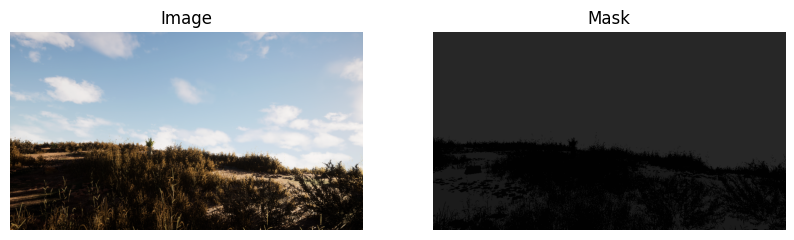

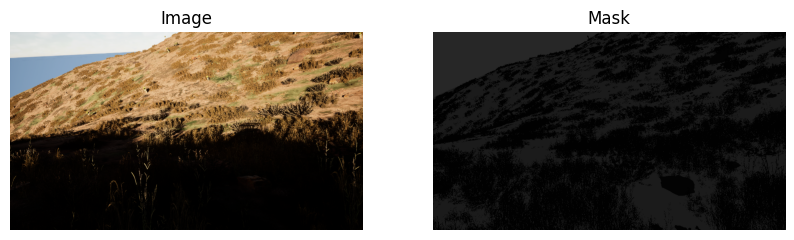

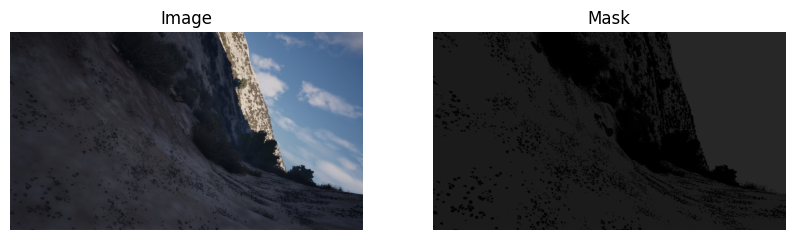

In [143]:
import cv2
import matplotlib.pyplot as plt
import random

def show_sample(idx):

    img = cv2.imread(str(train_images[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(str(train_masks[idx]))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")

    plt.show()

for _ in range(3):
    show_sample(random.randint(0, len(train_images)-1))

In [144]:
print(train_images[0].name)
print(train_masks[0].name)

cc0000012.png
cc0000012.png


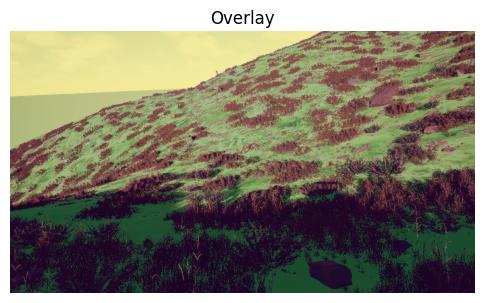

In [145]:
import cv2
import matplotlib.pyplot as plt

idx = 10

img = cv2.imread(str(train_images[idx]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(str(train_masks[idx]), 0)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.imshow(mask, alpha=0.4)
plt.title("Overlay")
plt.axis("off")
plt.show()

In [146]:
import numpy as np

mask = cv2.imread(str(train_masks[0]))
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

pixels = mask.reshape(-1,3)

unique_colors = np.unique(pixels, axis=0)

print("Unique mask colors:")
print(unique_colors)

print("\nNumber of classes:", len(unique_colors))

Unique mask colors:
[[ 0  0  0]
 [ 1  1  1]
 [ 2  2  2]
 [ 3  3  3]
 [27 27 27]
 [39 39 39]]

Number of classes: 6


In [147]:
img = cv2.imread(str(train_images[0]))
print("Image shape:", img.shape)

mask = cv2.imread(str(train_masks[0]))
print("Mask shape:", mask.shape)

Image shape: (540, 960, 3)
Mask shape: (540, 960, 3)


In [148]:
import numpy as np
import cv2

mask = cv2.imread(str(train_masks[0]))
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

pixels = mask.reshape(-1,3)
unique_colors = np.unique(pixels, axis=0)

print("Unique colors:")
print(unique_colors)

print("\nNumber of classes:", len(unique_colors))

Unique colors:
[[ 0  0  0]
 [ 1  1  1]
 [ 2  2  2]
 [ 3  3  3]
 [27 27 27]
 [39 39 39]]

Number of classes: 6


In [149]:
import numpy as np

ORIGINAL_LABELS = [0, 1, 2, 3, 27, 39]

LABEL_MAPPING = {v: i for i, v in enumerate(ORIGINAL_LABELS)}

print(LABEL_MAPPING)

{0: 0, 1: 1, 2: 2, 3: 3, 27: 4, 39: 5}


In [150]:
def convert_mask(mask):

    mask = mask[:,:,0]   #(converting rgb to grayscale)

    new_mask = np.zeros_like(mask)

    for old, new in LABEL_MAPPING.items():
        new_mask[mask == old] = new

    return new_mask

In [151]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 512

train_transform = A.Compose([
    
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),
    
    A.RandomBrightnessContrast(p=0.3),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=10,
        p=0.5
    ),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()
])

val_transform = A.Compose([
    
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    ),

    ToTensorV2()
])

In [152]:
import torch
from torch.utils.data import Dataset
import cv2

class OffroadDataset(Dataset):

    def __init__(self, images, masks, transform=None):
        
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = cv2.imread(str(self.images[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(self.masks[idx]))

        mask = convert_mask(mask)

        if self.transform:

            augmented = self.transform(
                image=img,
                mask=mask
            )

            img = augmented["image"]
            mask = augmented["mask"]

        return img, mask.long()

In [153]:
from torch.utils.data import DataLoader

train_dataset = OffroadDataset(
    train_images,
    train_masks,
    transform=train_transform
)

val_dataset = OffroadDataset(
    val_images,
    val_masks,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)


In [23]:
!pip install -q transformers timm

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [154]:
NUM_CLASSES = 6

model = SegformerForSemanticSegmentation.from_pretrained(
    
    "nvidia/segformer-b2-finetuned-ade-512-512",
    
    num_labels=NUM_CLASSES,
    
    ignore_mismatched_sizes=True
    
)

model = model.to(device)

print("Model loaded")

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([6, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded


In [26]:
for param in model.segformer.parameters():
    param.requires_grad = False

print("Backbone frozen")

Backbone frozen


In [27]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.softmax(logits, dim=1)

        targets_onehot = F.one_hot(targets, NUM_CLASSES)
        targets_onehot = targets_onehot.permute(0,3,1,2).float()

        intersection = (probs * targets_onehot).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets_onehot.sum(dim=(2,3))

        dice = (2*intersection + self.smooth) / (union + self.smooth)

        return 1 - dice.mean()

In [29]:
ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

def compute_loss(logits, masks):

    loss1 = ce_loss(logits, masks)
    loss2 = dice_loss(logits, masks)

    return loss1 + loss2

In [30]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [31]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

In [32]:
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_55/2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [33]:
def compute_iou(pred, mask):

    pred = pred.argmax(1)

    intersection = (pred == mask) & (mask > 0)
    union = (pred > 0) | (mask > 0)

    iou = intersection.sum().float() / (union.sum().float() + 1e-6)

    return iou.item()

In [34]:
EPOCHS = 20

best_iou = 0

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(pixel_values=images)
            logits = outputs.logits

            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = compute_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1} Train Loss:", train_loss/len(train_loader))

/tmp/ipykernel_55/581882002.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 Train Loss: 1.1544294701941187
Epoch 2 Train Loss: 0.897488581901156
Epoch 3 Train Loss: 0.8472723576276662
Epoch 4 Train Loss: 0.8223861094626634
Epoch 5 Train Loss: 0.8019404436289931
Epoch 6 Train Loss: 0.7862317653674653
Epoch 7 Train Loss: 0.7751754983510385
Epoch 8 Train Loss: 0.7663839630907474
Epoch 9 Train Loss: 0.7620225648640254
Epoch 10 Train Loss: 0.7541640775496733
Epoch 11 Train Loss: 0.7501673498633188
Epoch 12 Train Loss: 0.7426392750700093
Epoch 13 Train Loss: 0.741673451728661
Epoch 14 Train Loss: 0.7389812870731567
Epoch 15 Train Loss: 0.7374364011114536
Epoch 16 Train Loss: 0.7351271120529601
Epoch 17 Train Loss: 0.7339748075887478
Epoch 18 Train Loss: 0.732079101840877
Epoch 19 Train Loss: 0.7312384963701557
Epoch 20 Train Loss: 0.7321074170440269


In [35]:
    model.eval()

    val_iou = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)

            logits = outputs.logits

            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            val_iou += compute_iou(logits, masks)

    val_iou /= len(val_loader)

    print("Validation IoU:", val_iou)

    if val_iou > best_iou:

        best_iou = val_iou
        torch.save(model.state_dict(), "best_model.pth")

        print("Best model saved")

Validation IoU: 0.8530780225992203
Best model saved


In [36]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [39]:
for param in model.segformer.parameters():
    param.requires_grad = True

print("backbone unfrozen")

backbone unfrozen


In [41]:
import torch.optim as optim

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

In [43]:
loss = compute_loss(logits, masks)

In [44]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

In [47]:
import torch
torch.cuda.empty_cache()

In [48]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

/tmp/ipykernel_55/3522360610.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [52]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2
)

In [54]:
torch.backends.cudnn.benchmark = True

In [55]:
num_epochs = 15

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast():

            outputs = model(pixel_values=images).logits

            outputs = F.interpolate(
                outputs,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = compute_loss(outputs, masks)

        # Scaled backward pass
        scaler.scale(loss).backward()

        # Optimizer step with scaler
        scaler.step(optimizer)

        # Update scaler
        scaler.update()

        total_loss += loss.item()

    scheduler.step()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1} Train Loss: {avg_loss}")

/tmp/ipykernel_55/2687313727.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 Train Loss: 0.716760337144199
Epoch 2 Train Loss: 0.6767222948471427
Epoch 3 Train Loss: 0.6560215989011747
Epoch 4 Train Loss: 0.6418436663479468
Epoch 5 Train Loss: 0.6323100363482455
Epoch 6 Train Loss: 0.6237731034977608
Epoch 7 Train Loss: 0.6208670533479219
Epoch 8 Train Loss: 0.6153244762841098
Epoch 9 Train Loss: 0.6087359273825766
Epoch 10 Train Loss: 0.6057372631686313
Epoch 11 Train Loss: 0.6038295185340711
Epoch 12 Train Loss: 0.6035789636526181
Epoch 13 Train Loss: 0.6018349919350853
Epoch 14 Train Loss: 0.6004378786447417
Epoch 15 Train Loss: 0.6002301716821189


In [57]:
import torch
import torch.nn.functional as F

model.eval()

iou_total = 0
num_batches = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(pixel_values=images).logits

        # Resize predictions to match mask size
        outputs = F.interpolate(
            outputs,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        preds = torch.argmax(outputs, dim=1)

        intersection = ((preds == masks) & (masks > 0)).sum()
        union = ((preds > 0) | (masks > 0)).sum()

        iou = intersection.float() / union.float()

        iou_total += iou.item()
        num_batches += 1


val_iou = iou_total / num_batches

print("Validation IoU:", val_iou)

Validation IoU: 0.8680086357038725


In [58]:
if val_iou > best_iou:
    best_iou = val_iou
    torch.save(model.state_dict(), "best_model_stage2.pth")
    print("New best model saved")

New best model saved


In [59]:
import torch

model.load_state_dict(torch.load("best_model_stage2.pth"))
model = model.to(device)

print("Best model loaded")

Best model loaded


In [ ]:
import torch
import torch.nn.functional as F

model.eval()

iou_total = 0
num_batches = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(pixel_values=images).logits

        # Resize predictions
        outputs = F.interpolate(
            outputs,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        preds = torch.argmax(outputs, dim=1)

        intersection = ((preds == masks) & (masks > 0)).sum()
        union = ((preds > 0) | (masks > 0)).sum()

        iou = intersection.float() / union.float()

        iou_total += iou.item()
        num_batches += 1


test_iou = iou_total / num_batches

print("Test IoU:", test_iou)

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(pixel_values=images).logits

    outputs = F.interpolate(
        outputs,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

preds = torch.argmax(outputs, dim=1).cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(images[0].permute(1,2,0).cpu())

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(masks[0])

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(preds[0])

plt.show()

In [63]:
test_mask_base = Path("data/Offroad_Segmentation_testImages/Segmentation")
test_masks = list(test_mask_base.glob("*.png"))

print("Test images:", len(test_images))
print("Test masks:", len(test_masks))

Test images: 1002
Test masks: 1002


In [62]:
from pathlib import Path

test_mask_base = Path("data/Offroad_Segmentation_testImages/Segmentation")

print(test_mask_base.exists())

True


In [64]:
test_images = sorted(test_images)
test_masks = sorted(test_masks)

In [66]:
import cv2
import torch
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):

    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), 0)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [67]:
test_dataset = SegmentationDataset(
    test_images,
    test_masks,
    transform=val_transform
)

In [68]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [69]:
print(len(test_images), len(test_masks))

1002 1002


In [155]:
model.load_state_dict(torch.load("best_model_stage2.pth"))
model = model.to(device)
model.eval()

print("Best model loaded")

Best model loaded


In [164]:
from pathlib import Path

test_base = Path("data/Offroad_Segmentation_testImages")

for p in sorted(test_base.rglob("*")):
    if p.is_dir():
        files = list(p.glob("*"))
        print(f"{p}  →  {len(files)} files")

data/Offroad_Segmentation_testImages/Color_Images  →  1002 files
data/Offroad_Segmentation_testImages/Segmentation  →  1002 files


In [165]:
# ── STEP 2 & 3 ── Test Dataset and DataLoader ──────────────────────────────
from pathlib import Path
from torch.utils.data import DataLoader

TEST_DIR = Path("data/Offroad_Segmentation_testImages")

test_images = sorted(list((TEST_DIR / "Color_Images").glob("*.png")))
test_masks  = sorted(list((TEST_DIR / "Segmentation").glob("*.png")))

print(f"Test images : {len(test_images)}")
print(f"Test masks  : {len(test_masks)}")

assert len(test_images) == len(test_masks) and len(test_images) > 0

test_dataset = OffroadDataset(test_images, test_masks, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"Batches     : {len(test_loader)}")

Test images : 1002
Test masks  : 1002
Batches     : 126


In [166]:
# ── STEP 4 ── Sanity Checks ──────────────────────────────────────────────────
import torch

sample_imgs, sample_masks = next(iter(test_loader))

print("Image tensor  shape :", sample_imgs.shape)   # (B, 3, 512, 512)
print("Image tensor  dtype :", sample_imgs.dtype)
print("Mask tensor   shape :", sample_masks.shape)  # (B, 512, 512)
print("Mask tensor   dtype :", sample_masks.dtype)
print("Unique mask values  :", torch.unique(sample_masks).tolist())

# Quick forward pass to confirm output shape
model.eval()
with torch.no_grad():
    _logits = model(pixel_values=sample_imgs.to(device)).logits
    print("Raw logits    shape :", _logits.shape)    # (B, NUM_CLASSES, H/4, W/4)
del _logits


Image tensor  shape : torch.Size([8, 3, 512, 512])
Image tensor  dtype : torch.float32
Mask tensor   shape : torch.Size([8, 512, 512])
Mask tensor   dtype : torch.int64
Unique mask values  : [0, 1, 3, 4, 5]
Raw logits    shape : torch.Size([8, 6, 128, 128])


In [167]:
# ── STEP 5, 6 & 7 ── Inference, mIoU computation, Results ───────────────────
import torch
import torch.nn.functional as F
from tqdm import tqdm

model.eval()

# Per-class intersection and union accumulators
intersection = torch.zeros(NUM_CLASSES, dtype=torch.float64)
union        = torch.zeros(NUM_CLASSES, dtype=torch.float64)

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Test evaluation"):
        images = images.to(device)
        masks  = masks.to(device)

        # Forward pass
        logits = model(pixel_values=images).logits  # (B, C, H/4, W/4)

        # Resize logits to mask resolution
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )                                            # (B, C, H, W)

        preds = torch.argmax(logits, dim=1)          # (B, H, W)

        # Accumulate per-class intersection & union
        for cls in range(NUM_CLASSES):
            pred_c = (preds == cls)
            true_c = (masks == cls)
            intersection[cls] += (pred_c & true_c).sum().item()
            union[cls]        += (pred_c | true_c).sum().item()

# Per-class IoU
iou_per_class = []
for cls in range(NUM_CLASSES):
    if union[cls] == 0:
        iou_per_class.append(float("nan"))
    else:
        iou_per_class.append((intersection[cls] / union[cls]).item())

valid_ious = [v for v in iou_per_class if v == v]  # filter NaN
mean_iou   = sum(valid_ious) / len(valid_ious)

print("\n── Per-Class IoU ──────────────────────────────")
original_labels = [0, 1, 2, 3, 27, 39]
for cls, iou in enumerate(iou_per_class):
    label = original_labels[cls]
    if iou != iou:
        print(f"  Class {cls} (orig {label:>2})  IoU = N/A (not present)")
    else:
        print(f"  Class {cls} (orig {label:>2})  IoU = {iou:.4f}")

print("─" * 48)
print(f"  Test mIoU = {mean_iou:.4f}")

Test evaluation: 100%|██████████| 126/126 [01:00<00:00,  2.08it/s]


── Per-Class IoU ──────────────────────────────
  Class 0 (orig  0)  IoU = 0.5651
  Class 1 (orig  1)  IoU = 0.4697
  Class 2 (orig  2)  IoU = 0.0000
  Class 3 (orig  3)  IoU = 0.0414
  Class 4 (orig 27)  IoU = 0.6666
  Class 5 (orig 39)  IoU = 0.9835
────────────────────────────────────────────────
  Test mIoU = 0.4544


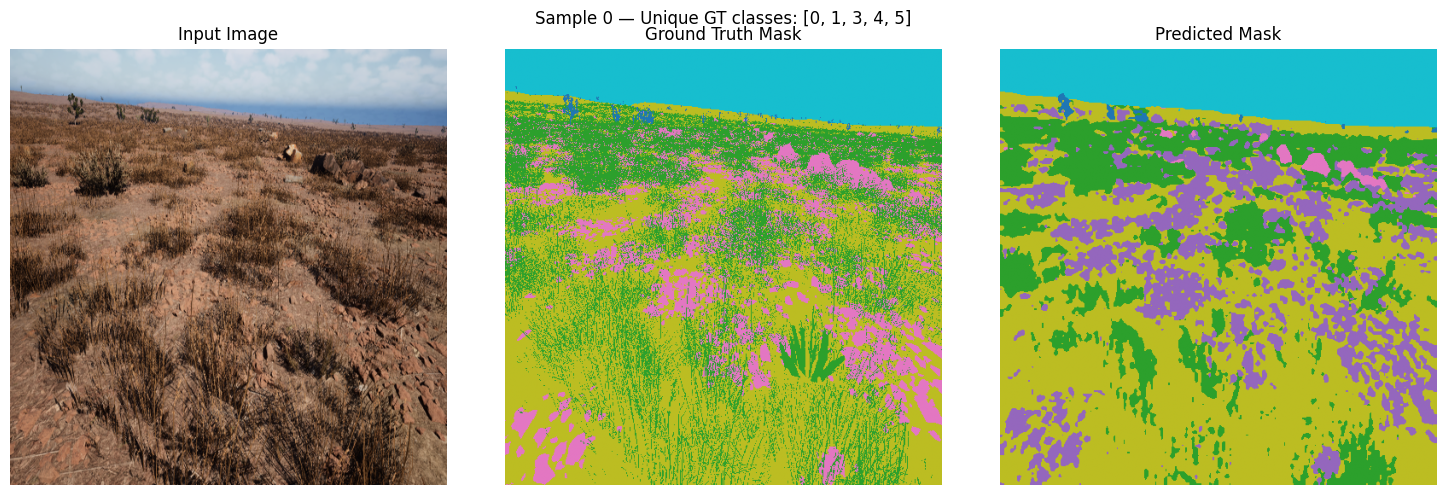

In [168]:
# ── STEP 8 ── Optional Visualisation (first batch sample) ───────────────────
import matplotlib.pyplot as plt
import numpy as np

# Un-normalise image for display
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

sample_imgs, sample_masks = next(iter(test_loader))

model.eval()
with torch.no_grad():
    logits = model(pixel_values=sample_imgs.to(device)).logits
    logits = F.interpolate(logits, size=sample_masks.shape[-2:],
                           mode="bilinear", align_corners=False)
    sample_preds = torch.argmax(logits, dim=1).cpu()

idx = 0   # change to inspect a different sample in the batch

img_np   = sample_imgs[idx].permute(1, 2, 0).numpy()
img_np   = np.clip(img_np * STD + MEAN, 0, 1)
gt_np    = sample_masks[idx].numpy()
pred_np  = sample_preds[idx].numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_np);          axes[0].set_title("Input Image");       axes[0].axis("off")
axes[1].imshow(gt_np,   vmin=0, vmax=NUM_CLASSES-1, cmap="tab10")
axes[1].set_title("Ground Truth Mask");  axes[1].axis("off")
axes[2].imshow(pred_np, vmin=0, vmax=NUM_CLASSES-1, cmap="tab10")
axes[2].set_title("Predicted Mask");     axes[2].axis("off")

plt.suptitle(f"Sample {idx} — Unique GT classes: {np.unique(gt_np).tolist()}")
plt.tight_layout()
plt.show()
